# AI-Based Household Energy Consumption Prediction

## Names and student numbers:
- Osama Alobaid - X00230146
- Almujtaba Mohamed - X00230145
- Hady Yousef - X00219585

## 1. Project Overview

The First Iteration will focus on:
-   Data Loading - This is done by importing and reading the data so the program can be able to read them.
-   Data Cleaning - This process is done by removing errors, correcting mistakes, filling missing values, and fixing broken data.
-   Data Preprocessing - The data is transformed into a format the program can learn and understand from. For example, converting dates  into a numbers.
-   Exploratory data analysis (EDA) - This process is basically us taking a good look over the data to understand what it contains.
-   Finding Initial Insights -  This part is drawing conclusions from data exploration.

## 2. Dataset Information

Datasets: Household Power Consumption Dataset  
Sources:
- Kaggle
- UCI
- UCI

Each of our rows displays one minute of household electricity consumption.


Our Key Features:
- Global_active_power
- Global_reactive_power
- Voltage
- Global_intensity
- Sub_metering_1
- Sub_metering_2
- Sub_metering_3

Our target variable is Global_active_power.

This is a regression problem.

### Import Required Libraries



The following libraries are used for loading the dataset, handling missing values, detecting outliers, processing the data, and preparing it for machine learning models.

In [116]:
import numpy as np
import joblib
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## Load and Prepare Datasets

### Load and prepare dataset 

Firstly , this section loads the first dataset in a pandas dataframe. The data set has household electricity consumption measurements that are recorded over time. Secondly, the structure of the data is inspected and unnecessary columns are removed. Thirdly, The first few rows are displayed and data shape is printed. Finally, converting data type of certain columns to numeric and dealing with missing values.

In [117]:
filename1 = 'hy_kaggle_household_power_consumption.csv'# Load the dataset file as filename1
data1 = pd.read_csv(filename1)# Read the CSV file into a pandas DataFrame
data1 = data1.drop(columns=['index'])#removing unecessary index column
print("Data shape:", data1.shape)#print data shape
data1.head()#Display first 5 rows

Data shape: (260640, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,01/01/2007,0:00:00,2.58,0.136,241.97,10.6,0,0,0.0
1,01/01/2007,0:01:00,2.552,0.1,241.75,10.4,0,0,0.0
2,01/01/2007,0:02:00,2.55,0.1,241.64,10.4,0,0,0.0
3,01/01/2007,0:03:00,2.55,0.1,241.71,10.4,0,0,0.0
4,01/01/2007,0:04:00,2.554,0.1,241.98,10.4,0,0,0.0


In [118]:
cols1=[#List of containg name columns 
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

data1[cols1]= data1[cols1].apply(pd.to_numeric, errors="coerce")# Convert selected columns to numeric values and converting values that cant be converted to numeric to nan

In [119]:
#Replace any missing value NAN to the median of the column
data1['Global_active_power'].fillna(data1['Global_active_power'].median(), inplace=True) 
data1['Global_reactive_power'].fillna(data1['Global_reactive_power'].median(), inplace=True)
data1['Voltage'].fillna(data1['Voltage'].median(), inplace=True)
data1['Global_intensity'].fillna(data1['Global_intensity'].median(), inplace=True)
data1['Sub_metering_1'].fillna(data1['Sub_metering_1'].median(), inplace=True)
data1['Sub_metering_2'].fillna(data1['Sub_metering_2'].median(), inplace=True)
data1['Sub_metering_3'].fillna(data1['Sub_metering_3'].median(), inplace=True)

C:\Users\almujtaba\AppData\Local\Temp\ipykernel_20932\1567363176.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data1['Global_active_power'].fillna(data1['Global_active_power'].median(), inplace=True)
C:\Users\almujtaba\AppData\Local\Temp\ipykernel_20932\1567363176.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are s

In [120]:
filename2 = 'MJ_household_power_consumption.csv'# Load the dataset file as filename2
data2 = pd.read_csv(filename2, na_values='?', low_memory=False)# Read the CSV file into a pandas DataFrame, treat ? as nan and read the file in one pass
print("Data shape:", data2.shape)#print data shape
data2.head()#Display first 5 rows

Data shape: (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [121]:
cols2=[#List of containg name columns
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

data2[cols2]= data2[cols2].apply(pd.to_numeric, errors="coerce")# Convert selected columns to numeric values and converting values that cant be converted to numeric to nan

In [122]:
#Replace any missing value NAN to the median of the column
data2['Global_active_power'].fillna(data2['Global_active_power'].median(), inplace=True)
data2['Global_reactive_power'].fillna(data2['Global_reactive_power'].median(), inplace=True)
data2['Voltage'].fillna(data2['Voltage'].median(), inplace=True)
data2['Global_intensity'].fillna(data2['Global_intensity'].median(), inplace=True)
data2['Sub_metering_1'].fillna(data2['Sub_metering_1'].median(), inplace=True)
data2['Sub_metering_2'].fillna(data2['Sub_metering_2'].median(), inplace=True)
data2['Sub_metering_3'].fillna(data2['Sub_metering_3'].median(), inplace=True)

C:\Users\almujtaba\AppData\Local\Temp\ipykernel_20932\725224325.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data2['Global_active_power'].fillna(data2['Global_active_power'].median(), inplace=True)
C:\Users\almujtaba\AppData\Local\Temp\ipykernel_20932\725224325.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are set

In [123]:
filename3 = 'oa_archive_household_power_consumption.csv'# Load the dataset file as filename3
data3 = pd.read_csv(filename3)# Read the CSV file into a pandas DataFrame
print("Data shape:", data3.shape)#print data shape
data3.head()#display first 5 rows

Data shape: (1048575, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [124]:
cols3=[# list containg name of columns
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

data3[cols3]= data3[cols3].apply(pd.to_numeric, errors="coerce")# Convert selected columns to numeric values and converting values that cant be converted to numeric to nan

In [125]:
#Replace any missing value NAN to the median of the column
data3['Global_active_power'].fillna(data3['Global_active_power'].median(), inplace=True)
data3['Global_reactive_power'].fillna(data3['Global_reactive_power'].median(), inplace=True)
data3['Voltage'].fillna(data3['Voltage'].median(), inplace=True)
data3['Global_intensity'].fillna(data3['Global_intensity'].median(), inplace=True)
data3['Sub_metering_1'].fillna(data3['Sub_metering_1'].median(), inplace=True)
data3['Sub_metering_2'].fillna(data3['Sub_metering_2'].median(), inplace=True)
data3['Sub_metering_3'].fillna(data3['Sub_metering_3'].median(), inplace=True)

C:\Users\almujtaba\AppData\Local\Temp\ipykernel_20932\2929620106.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data3['Global_active_power'].fillna(data3['Global_active_power'].median(), inplace=True)
C:\Users\almujtaba\AppData\Local\Temp\ipykernel_20932\2929620106.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are s

In [126]:
#Display information about each data set column names,data types and number of null values
data1.info()
data2.info()
data3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260640 entries, 0 to 260639
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Date                   260640 non-null  object 
 1   Time                   260640 non-null  object 
 2   Global_active_power    260640 non-null  float64
 3   Global_reactive_power  260640 non-null  float64
 4   Voltage                260640 non-null  float64
 5   Global_intensity       260640 non-null  float64
 6   Sub_metering_1         260640 non-null  float64
 7   Sub_metering_2         260640 non-null  float64
 8   Sub_metering_3         260640 non-null  float64
dtypes: float64(7), object(2)
memory usage: 17.9+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object

In [127]:
data1.describe()#displays a summary of statistics of numeric columns 

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,260640.000000,260640.000000,260640.000000,260640.000000,260640.000000,260640.000000,260640.000000
mean,1.156242,0.123443,239.214783,4.940397,1.313202,1.646440,5.747449
std,1.175444,0.111084,3.567029,4.971289,6.658190,6.586236,8.157050
min,0.082000,0.000000,223.490000,0.400000,0.000000,0.000000,0.000000
25%,0.298000,0.000000,236.700000,1.400000,0.000000,0.000000,0.000000
50%,0.564000,0.104000,239.610000,2.600000,0.000000,0.000000,0.000000
75%,1.590000,0.192000,241.780000,6.800000,0.000000,1.000000,17.000000
max,10.670000,1.148000,250.890000,46.400000,78.000000,78.000000,20.000000


In [128]:
data2.describe()#displays a summary of statistics of numeric columns 

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.075259e+06,2.075259e+06,2.075259e+06,2.075259e+06,2.075259e+06,2.075259e+06,2.075259e+06
mean,1.085486e+00,1.234176e-01,2.408420e+02,4.602375e+00,1.107879e+00,1.282265e+00,6.390116e+00
std,1.052065e+00,1.120452e-01,3.219699e+00,4.422241e+00,6.115669e+00,5.787271e+00,8.406114e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.100000e-01,4.800000e-02,2.390200e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.520000e+00,1.920000e-01,2.428600e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


In [129]:
data3.describe()#displays a summary of statistics of numeric columns 

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,1.106036e+00,1.181945e-01,2.399608e+02,4.709127e+00,1.172882e+00,1.469452e+00,5.910810e+00
std,1.127886e+00,1.093008e-01,3.278162e+00,4.756521e+00,6.309331e+00,6.341029e+00,8.202752e+00
min,7.600000e-02,0.000000e+00,2.234900e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.880000e-01,0.000000e+00,2.379800e+02,1.200000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,5.500000e-01,9.800000e-02,2.402100e+02,2.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.542000e+00,1.860000e-01,2.421400e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.067000e+01,1.390000e+00,2.521400e+02,4.640000e+01,8.000000e+01,7.800000e+01,3.100000e+01


In [130]:
# Missing values summary
data1.isna().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [131]:
# Missing values summary
data2.isna().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [132]:
# Missing values summary
data3.isna().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

## Data Cleaning & Pre processing

### Duplicate detection and cleaning

This part focuses on detecting duplicates and removing them and diplaying the final shape of data


In [133]:
duplicates = data1.duplicated().sum()# check for duplicate row in set1 and count duplicate rows
print("Duplicate rows:", duplicates)#print the number of duplicate rows

print("Data shape before dropping duplicates:", data1.shape)#Print data shape


if duplicates > 0:#check if duplicates exist
    data1 = data1.drop_duplicates()

print(f"\nData shape after dropping duplicates:", data1.shape)#Print data shape


Duplicate rows: 0
Data shape before dropping duplicates: (260640, 9)

Data shape after dropping duplicates: (260640, 9)


In [134]:
duplicates = data2.duplicated().sum()# check for duplicate row in set2 and count duplicate rows
print("Duplicate rows:", duplicates)#print the number of duplicate rows

print("Data shape before dropping duplicates:", data2.shape)#Print data shape


if duplicates > 0:#check if duplicates exist
    data2 = data2.drop_duplicates()

print(f"\nData shape after dropping duplicates:", data2.shape)#Print data shape


Duplicate rows: 0
Data shape before dropping duplicates: (2075259, 9)

Data shape after dropping duplicates: (2075259, 9)


In [135]:
duplicates = data3.duplicated().sum()# check for duplicate row in set3 and count duplicate rows
print("Duplicate rows:", duplicates)#print the number of duplicate rows

print("Data shape before dropping duplicates:", data3.shape)#Print data shape

if duplicates > 0:#check if duplicates exist
    data3 = data3.drop_duplicates()

print(f"\nData shape after dropping duplicates:", data3.shape)#Print data shape


Duplicate rows: 0
Data shape before dropping duplicates: (1048575, 9)

Data shape after dropping duplicates: (1048575, 9)


## Outliers

### Outlier detection and removal
In this step Numerical and categorical columns are identified , boxplots are used to visually inspect outliers and The Interquartile Range (IQR) method is used to detect and remove outliers.
The process of dealing with outliers is a little bit more complicated. We need to first identify what would classify as an outlier by using Interquartile Range (IQR) method.By creating range for data by subtracting the first quartile from the third quartile we have our accept range and every thing not within is and outlier we need to remove.

Categorical columns: []
Numerical columns: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
Shape before outlier removal: (260640, 9)


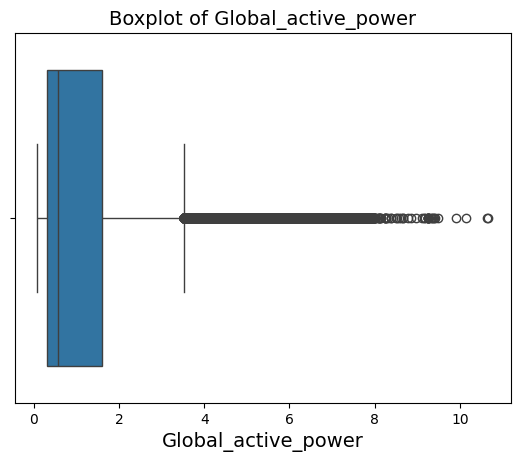

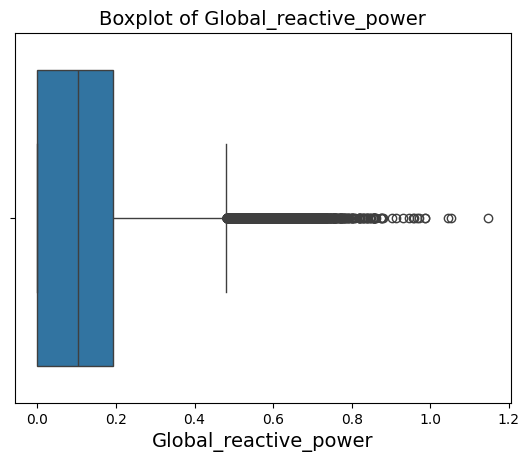

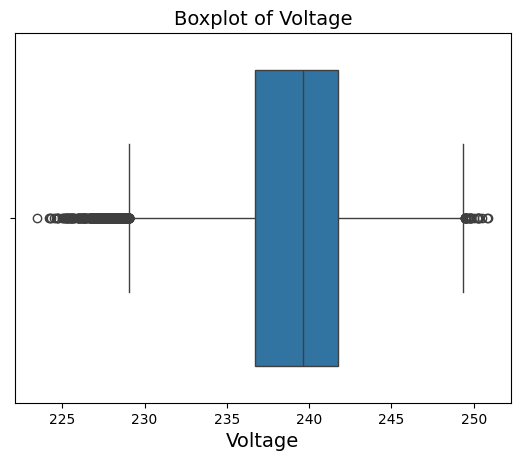

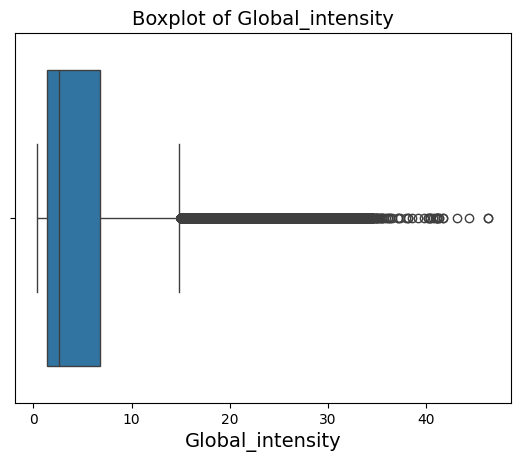

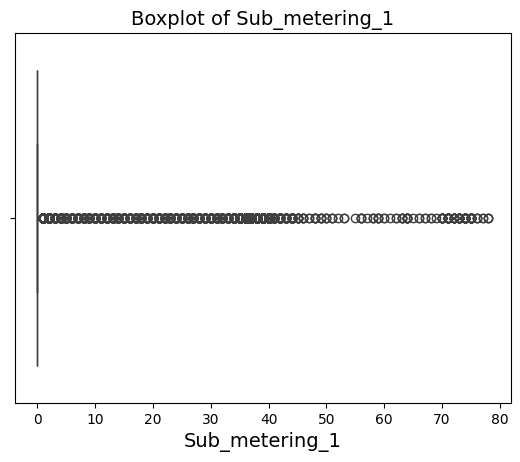

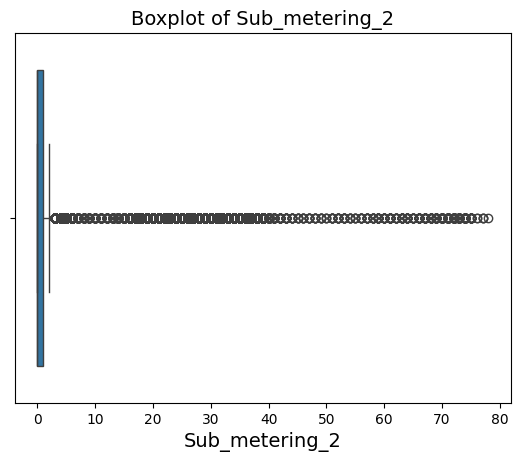

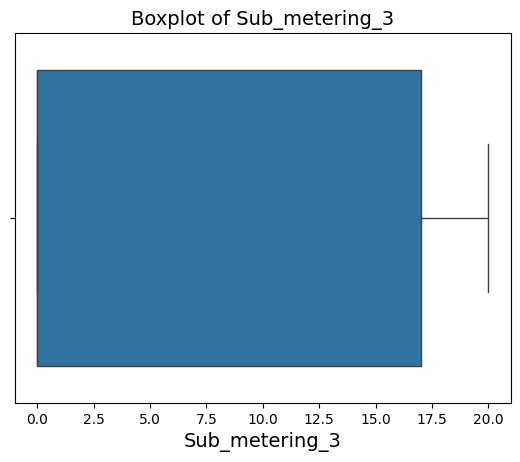

Shape after outlier removal: (220239, 9)


In [136]:
cat_col1 = [col for col in data1.columns if data1[col].dtype == 'string']#categorical columns string type
num_col1= [col for col in data1.columns if data1[col].dtype == 'float' ]#numerical columns float type
# Print column types
print('Categorical columns:', cat_col1)
print('Numerical columns:', num_col1)


print("Shape before outlier removal:", data1.shape)# printdataset size before removing outliers


for col in num_col1:# Plot boxplots to visually detect outliers
    sns.boxplot(x=data1[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


for col in num_col1:# Remove outliers using the IQR method
    Q1 = data1[col].quantile(0.25)   # Calculate quartiles
    Q3 = data1[col].quantile(0.75)
    IQR = Q3 - Q1   # Calculate IQR
    lower = Q1 - 1.5 * IQR# lower limits
    upper = Q3 + 1.5 * IQR# upper limits
    data1 = data1[(data1[col] >= lower) & (data1[col] <= upper)] # Filter the dataset to remove outliers

print("Shape after outlier removal:", data1.shape)# print dataset size after removing outliers



Categorical columns: []
Numerical columns: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
Shape before outlier removal: (2075259, 9)


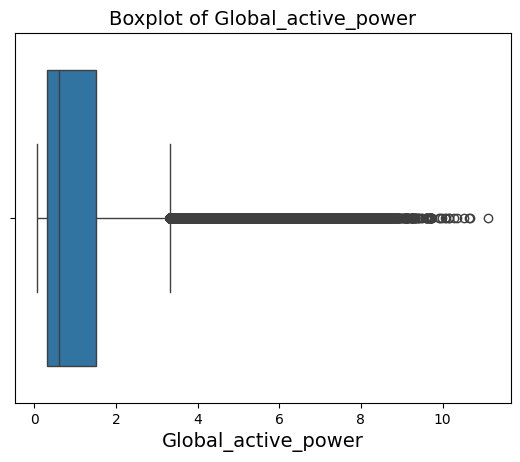

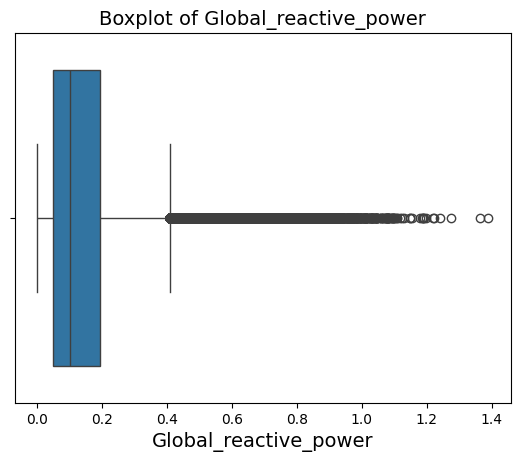

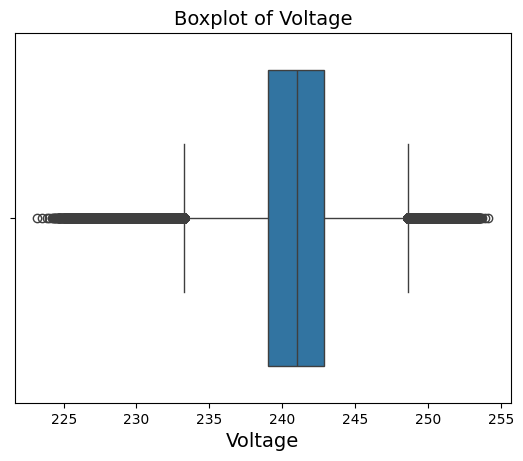

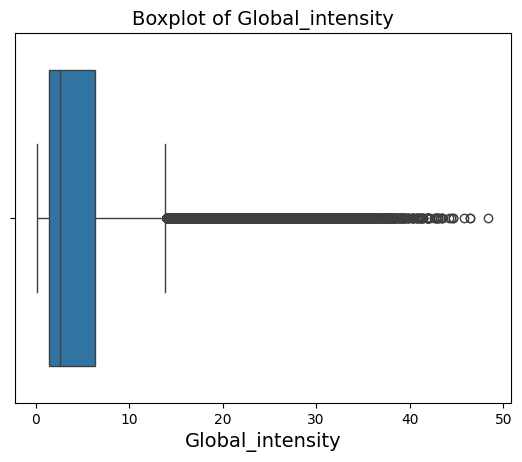

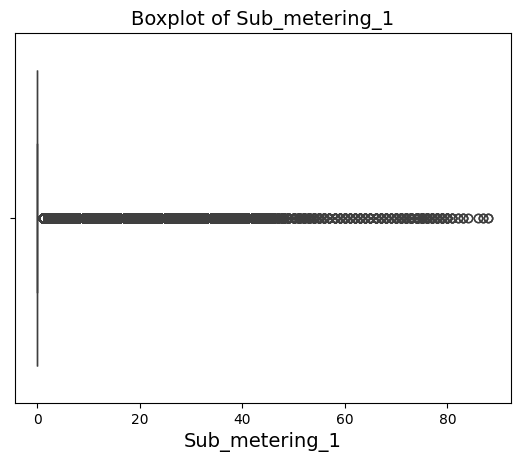

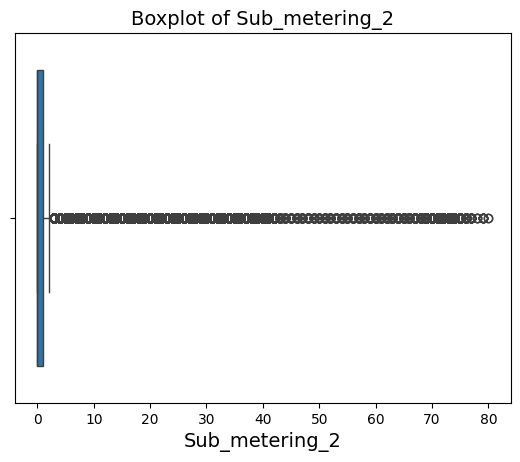

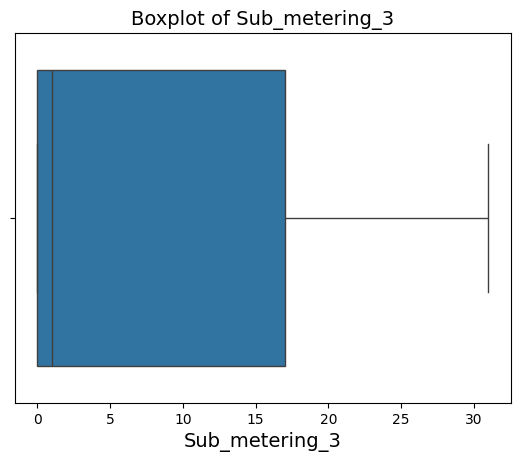

Shape after outlier removal: (1739080, 9)


In [137]:
cat_col2 = [col for col in data2.columns if data2[col].dtype == 'string']#categorical columns string type
num_col2= [col for col in data2.columns if data2[col].dtype == 'float' ]#numerical columns float type

# Print column types
print('Categorical columns:', cat_col2)
print('Numerical columns:', num_col2)


print("Shape before outlier removal:", data2.shape)# print dataset size before removing outliers


for col in num_col2:# Plot boxplots to visually detect outliers
    sns.boxplot(x=data2[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


for col in num_col2:# Remove outliers using the IQR method
    Q1 = data2[col].quantile(0.25)# Calculate quartiles
    Q3 = data2[col].quantile(0.75)
    IQR = Q3 - Q1 # Calculate IQR
    lower = Q1 - 1.5 * IQR# lower limits
    upper = Q3 + 1.5 * IQR# upper limits
    data2 = data2[(data2[col] >= lower) & (data2[col] <= upper)]# Filter the dataset to remove outliers

print("Shape after outlier removal:", data2.shape)# print dataset size after removing outliers

Categorical: []
Numerical: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
Shape before outlier removal: (1048575, 9)


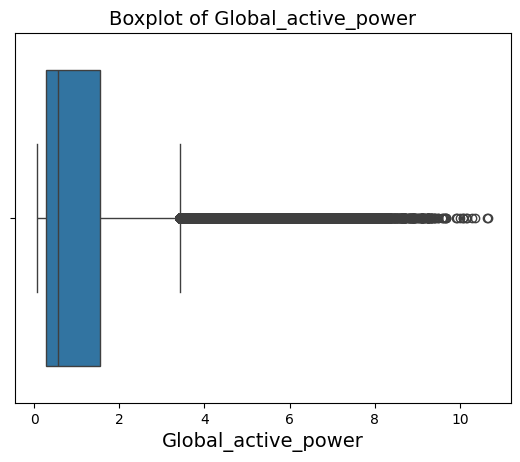

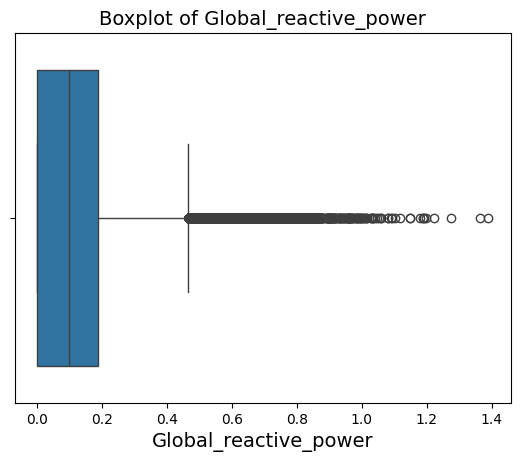

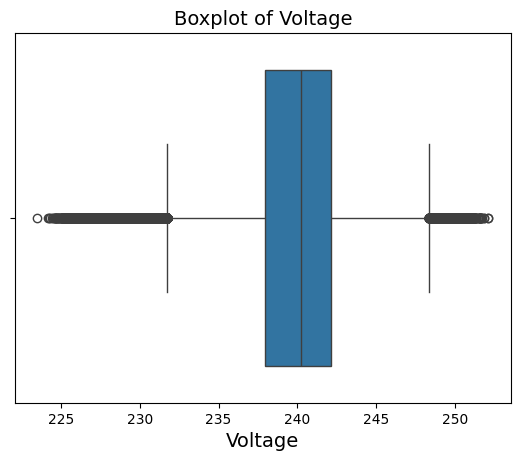

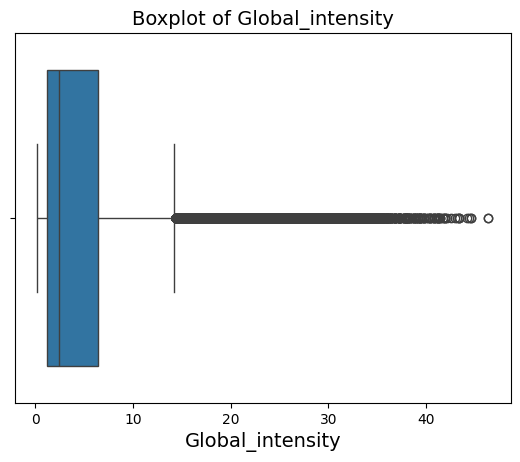

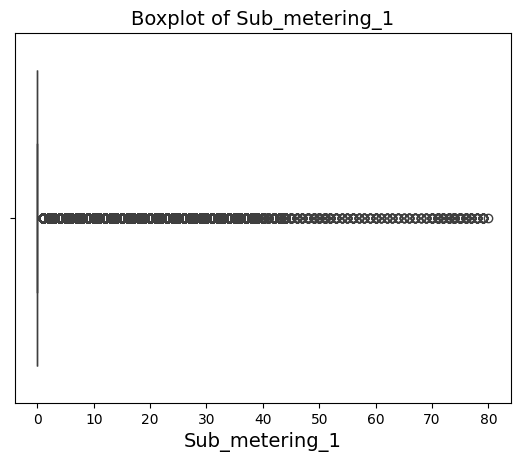

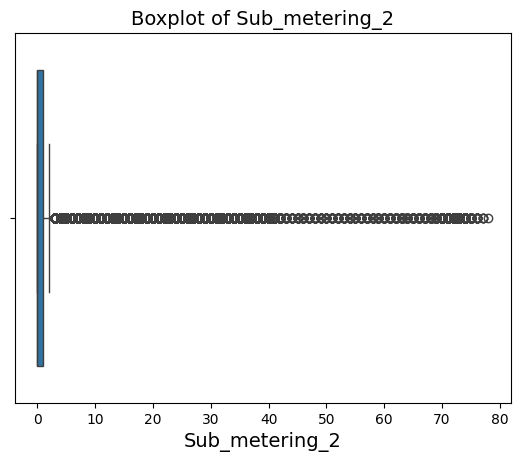

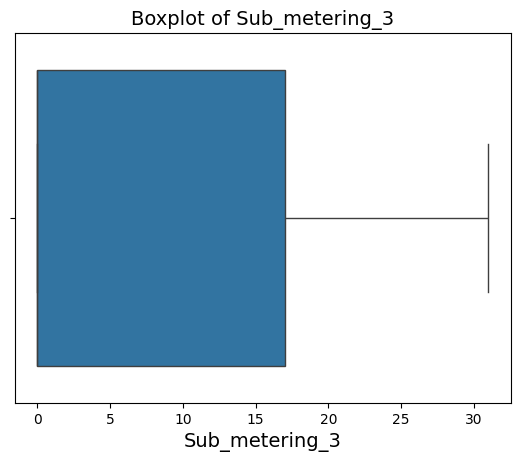

Shape after outlier removal: (887107, 9)


In [138]:
cat_col3 = [col for col in data3.columns if data3[col].dtype == 'string']#categorical columns string type
num_col3 = [col for col in data3.columns if data3[col].dtype == 'float' ]#numerical columns float type
# Print column types
print("Categorical:", cat_col3)
print("Numerical:", num_col3)

print("Shape before outlier removal:", data3.shape)# print dataset size before removing outliers


for col in num_col3:# Plot boxplots to visually detect outliers
    sns.boxplot(x=data3[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


for col in num_col3:# Remove outliers using the IQR method
    Q1 = data3[col].quantile(0.25)# Calculate quartiles
    Q3 = data3[col].quantile(0.75)
    IQR = Q3 - Q1 # Calculate IQR
    lower = Q1 - 1.5 * IQR# lower limits
    upper = Q3 + 1.5 * IQR# upper limits
    data3 = data3[(data3[col] >= lower) & (data3[col] <= upper)]# Filter the dataset to remove outliers

print("Shape after outlier removal:", data3.shape)# print dataset size after removing outliers

### Data Visualization

For better understanding of numeric numerical variables, histograms and density plots are created.

### Visualization 

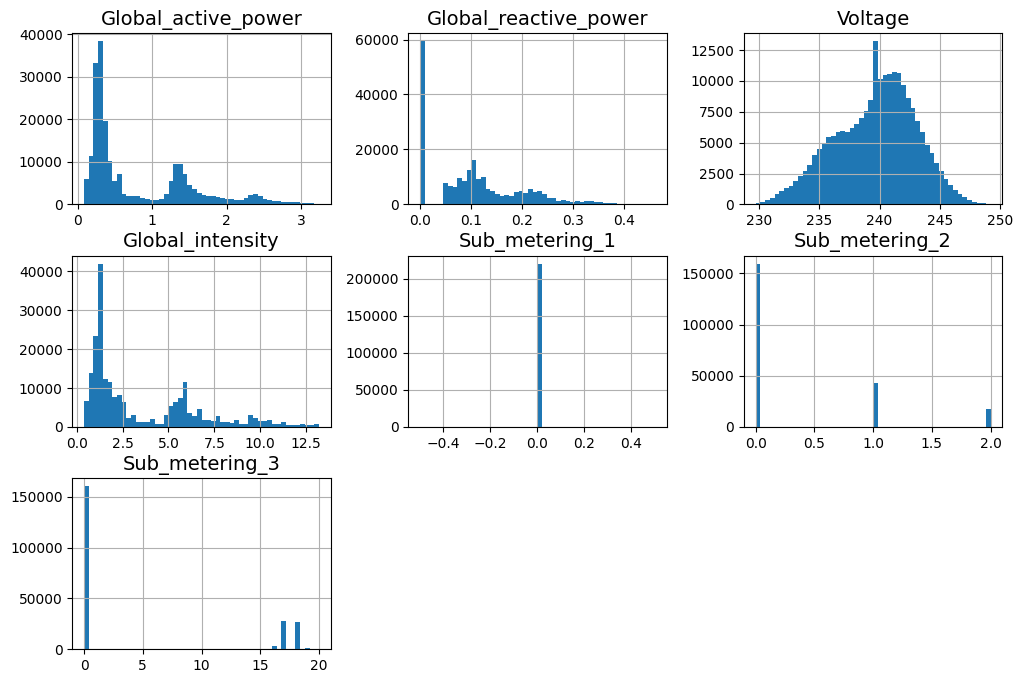

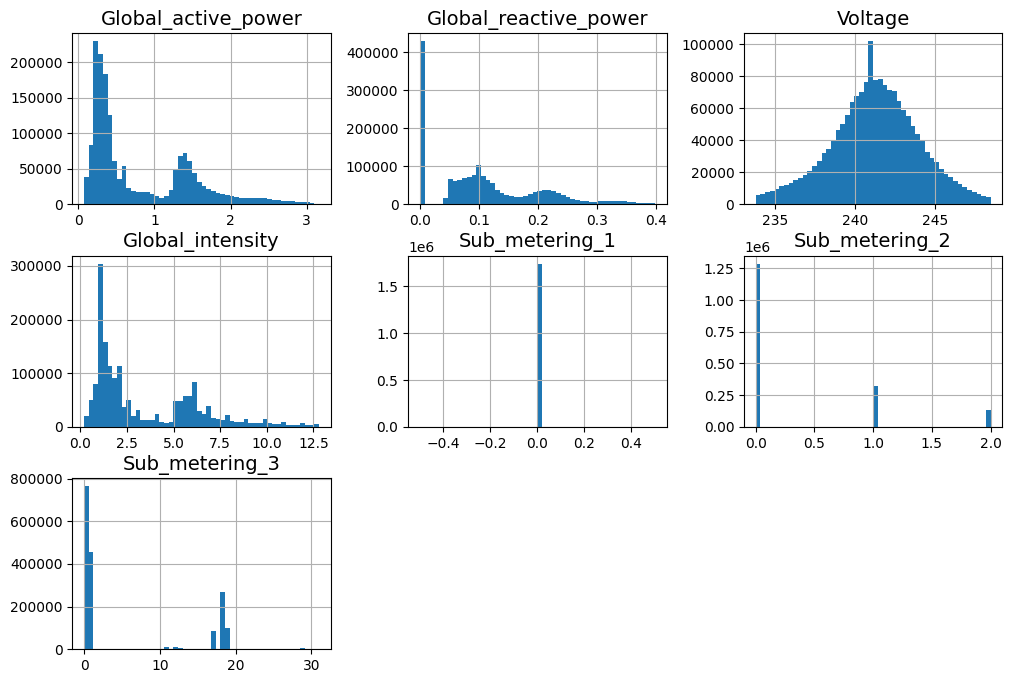

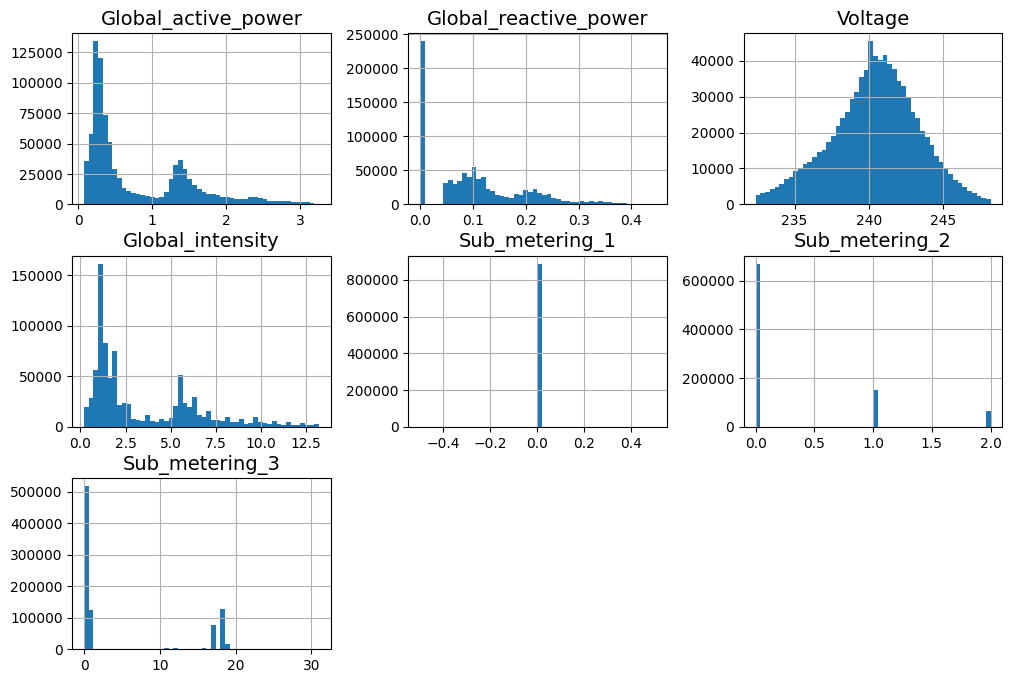

In [139]:
# Set plot style and font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
# Plot histograms for each dataset
data1.hist(bins=50, figsize=(12, 8))
data2.hist(bins=50, figsize=(12, 8))
data3.hist(bins=50, figsize=(12, 8))

plt.show()#displays 

## Intepretation for histograms
Most variables are right skewed wich mean higher values occur rarely.
Voltage apears to follow normal distribution.
sub_metering variables has zeros, indicating energy usage in these meters is often low.

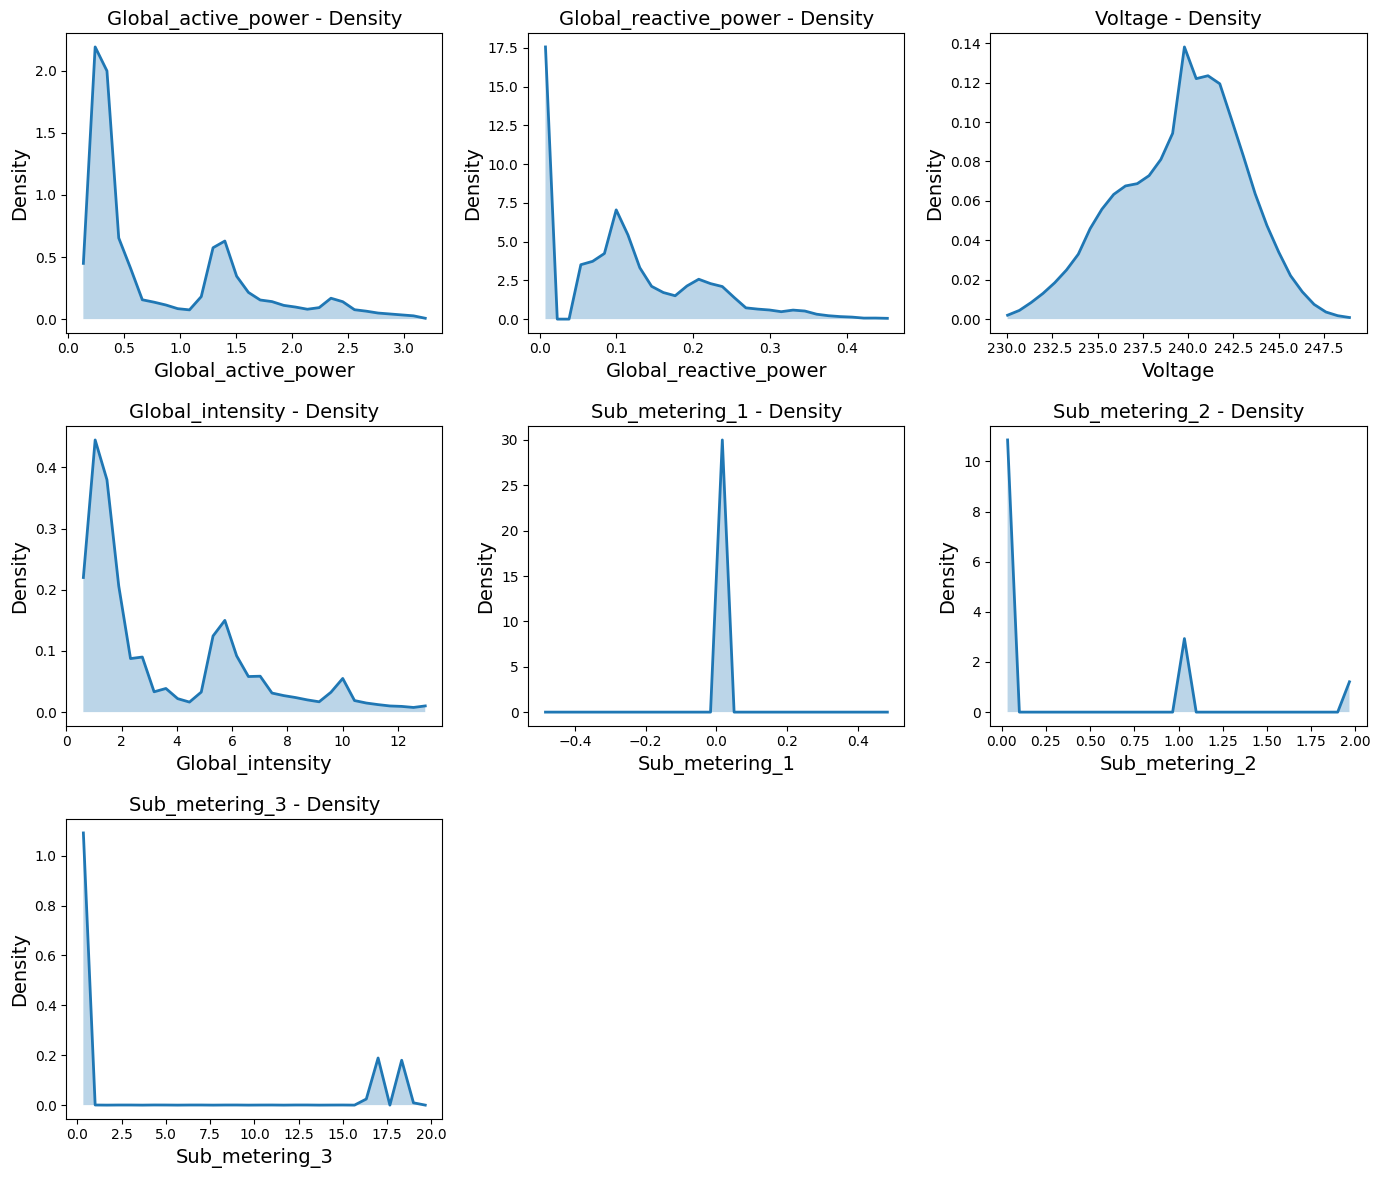

In [140]:
plt.figure(figsize=(14, 12))# Create a large figure to display multiple density plots

# Loop through numerical columns
for i, fname in enumerate(num_col1):
    values = data1[fname].values # Extract column values 
    
    counts, bins = np.histogram(values, bins=30, density=True)# Compute histogram values for density estimation
    bin_centers = 0.5 * (bins[1:] + bins[:-1])# Compute bin centers

    
    plt.subplot(3, 3, i+1)# Create subplot for each variable
    plt.plot(bin_centers, counts, linewidth=2)# Plot density curve
    plt.fill_between(bin_centers, counts, alpha=0.3)# Fill area under the curve
    plt.title(f"{fname} - Density")# Set plot labels
    plt.xlabel(fname)
    plt.ylabel("Density")

plt.tight_layout()# Adjust subplot layout
plt.show()# Display plots

### Density Plot Interpretation
Most variables are right skewed wich mean higher values occur rarely.
Voltage apears to follow normal distribution.
sub_metering variables has zeros, indicating energy usage in these meters is often low or not active.


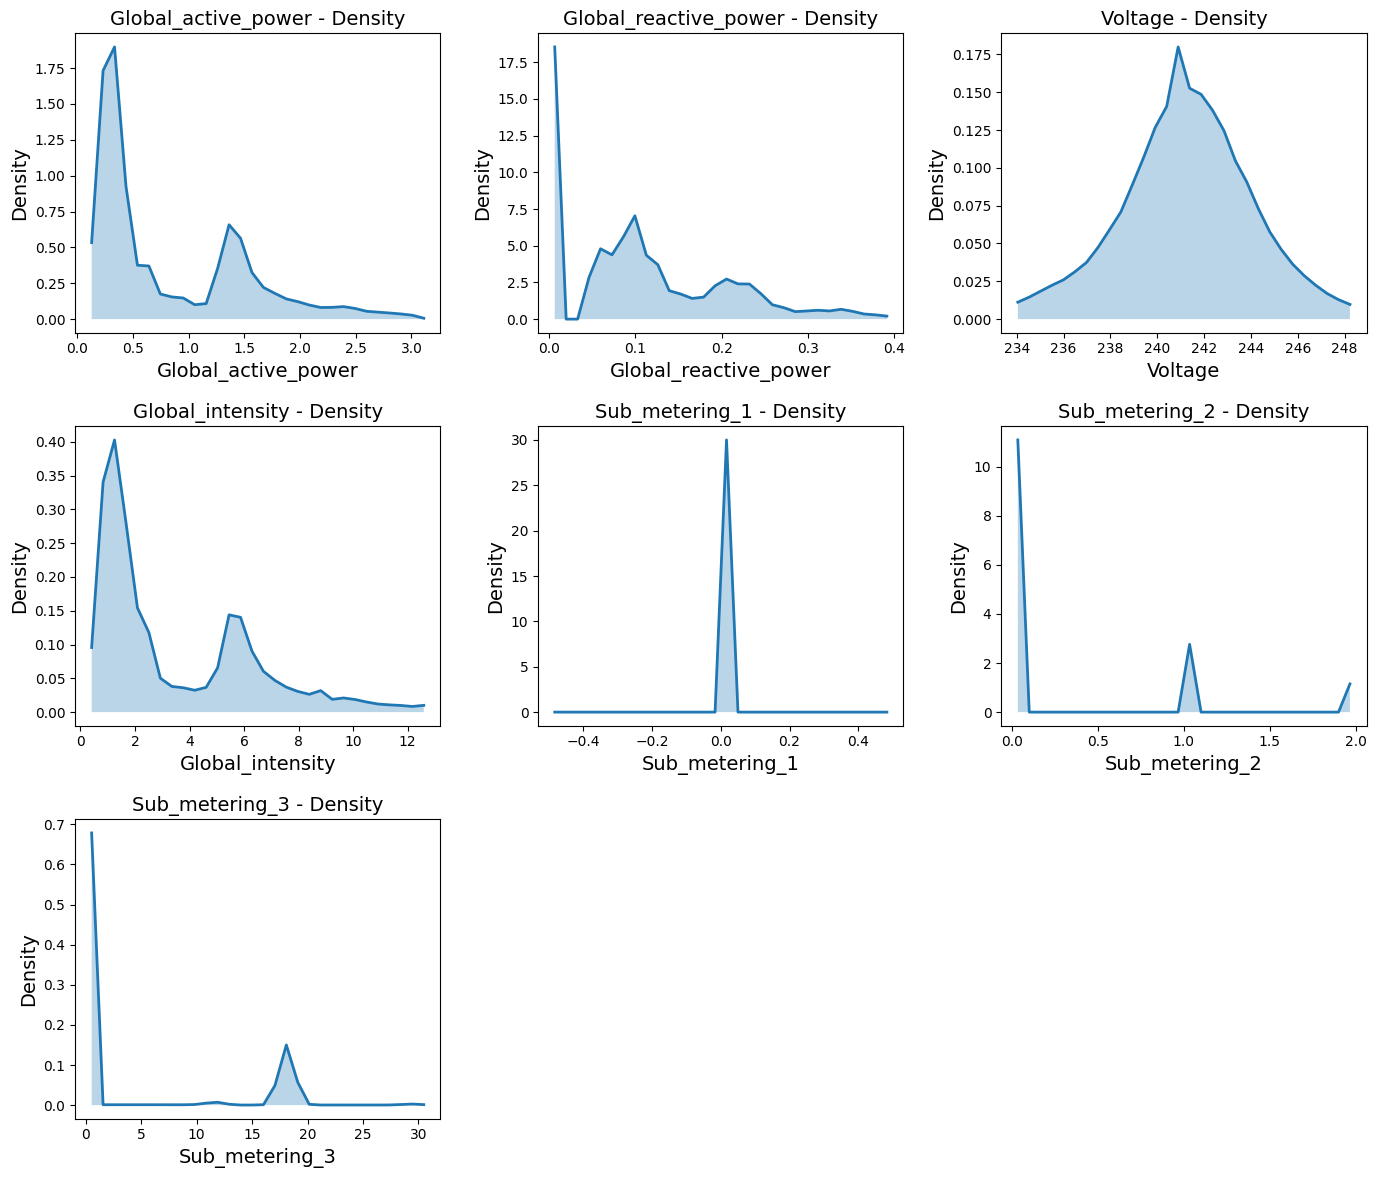

In [141]:
plt.figure(figsize=(14, 12))# Create a large figure to display multiple density plots

# Loop through numerical columns
for i, fname in enumerate(num_col2):
    values = data2[fname].values  # Extract column values 
    
    counts, bins = np.histogram(values, bins=30, density=True)# Compute histogram values for density estimation
    bin_centers = 0.5 * (bins[1:] + bins[:-1])# Compute bin centers
    
    plt.subplot(3, 3, i+1)# Create subplot for each variable
    plt.plot(bin_centers, counts, linewidth=2)# Plot density curve
    plt.fill_between(bin_centers, counts, alpha=0.3)# Fill area under the curve
    plt.title(f"{fname} - Density")# Set plot labels
    plt.xlabel(fname)
    plt.ylabel("Density")

plt.tight_layout()# Adjust subplot layout
plt.show()# Display plots

### Density Plot Interpretation Dataset 2
Most variables are right skewed wich mean higher values occur rarely.
Voltage apears to follow normal distribution.
sub_metering variables has zeros, indicating energy usage in these meters is often low or not active.

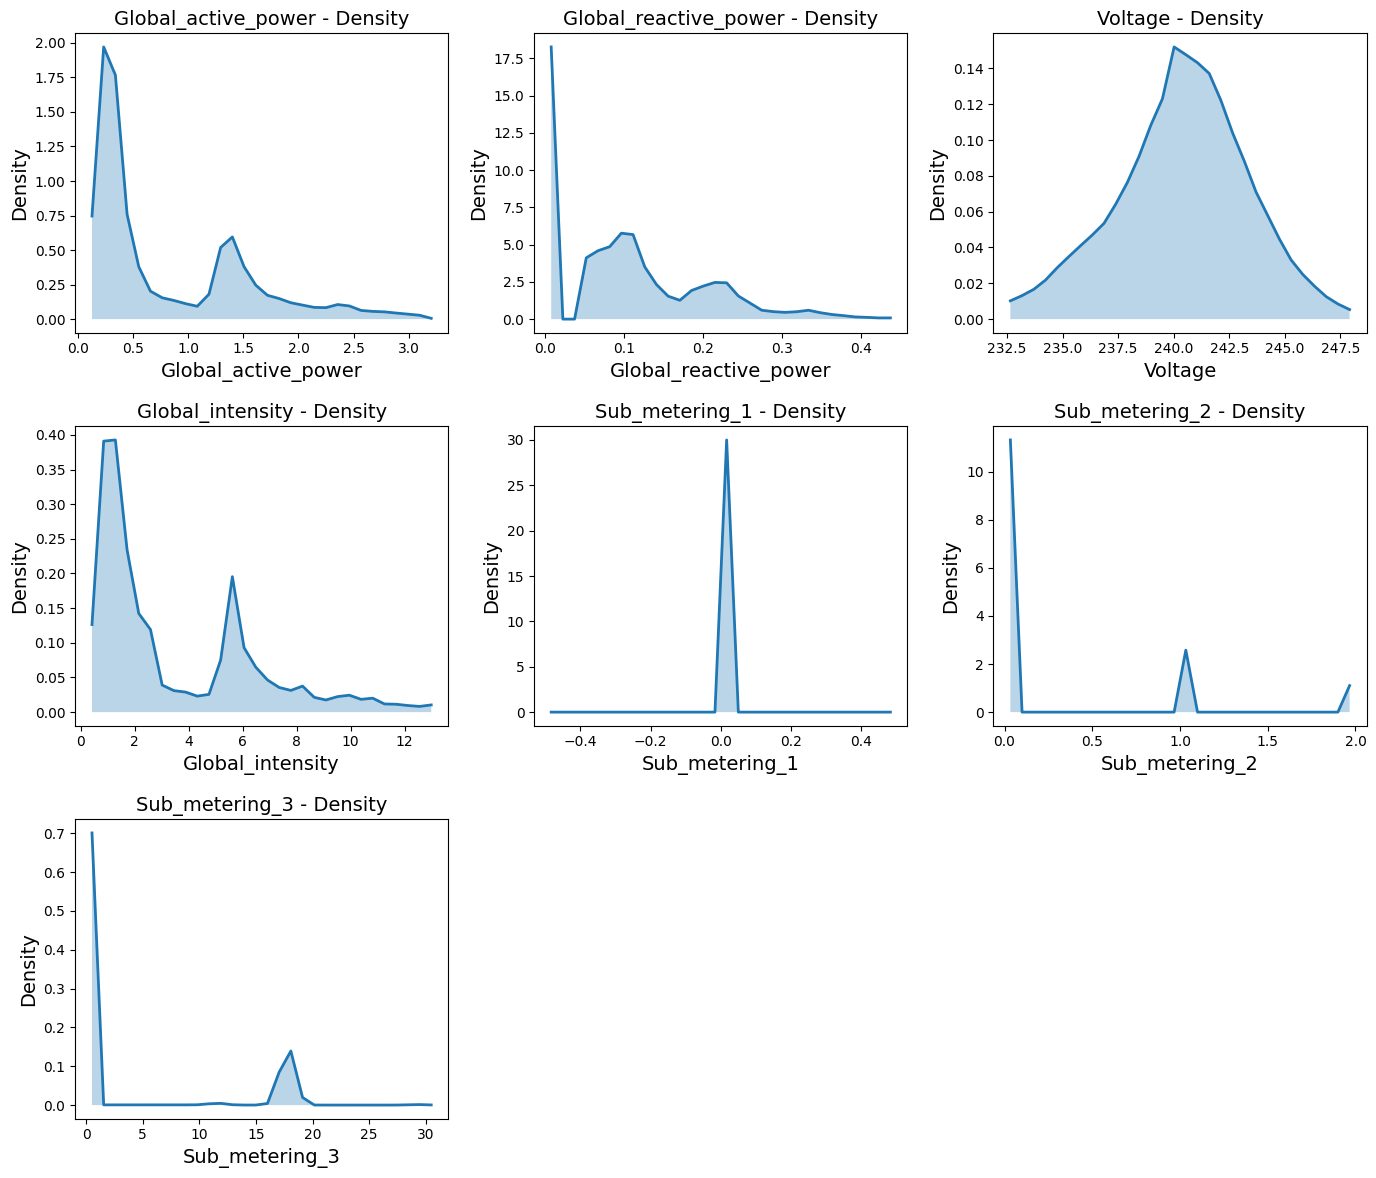

In [142]:
plt.figure(figsize=(14, 12))# Create a large figure to display multiple density plots
# Loop through numerical columns
for i, fname in enumerate(num_col3):
    values = data3[fname].values  # Extract column values 
    
    counts, bins = np.histogram(values, bins=30, density=True)# Compute histogram values for density estimation
    bin_centers = 0.5 * (bins[1:] + bins[:-1])# Compute bin centers
    
    plt.subplot(3, 3, i+1)# Create subplot for each variable
    plt.plot(bin_centers, counts, linewidth=2)# Plot density curve
    plt.fill_between(bin_centers, counts, alpha=0.3)# Fill area under the curve
    plt.title(f"{fname} - Density")# Set plot labels
    plt.xlabel(fname)
    plt.ylabel("Density")

plt.tight_layout()# Adjust subplot layout
plt.show()# Display plots

### Density Plot Interpretation Dataset 3
Most variables are right skewed wich mean higher values occur rarely.
Voltage apears to follow normal distribution.
sub_metering variables has zeros, indicating energy usage in these meters is often low or not active.

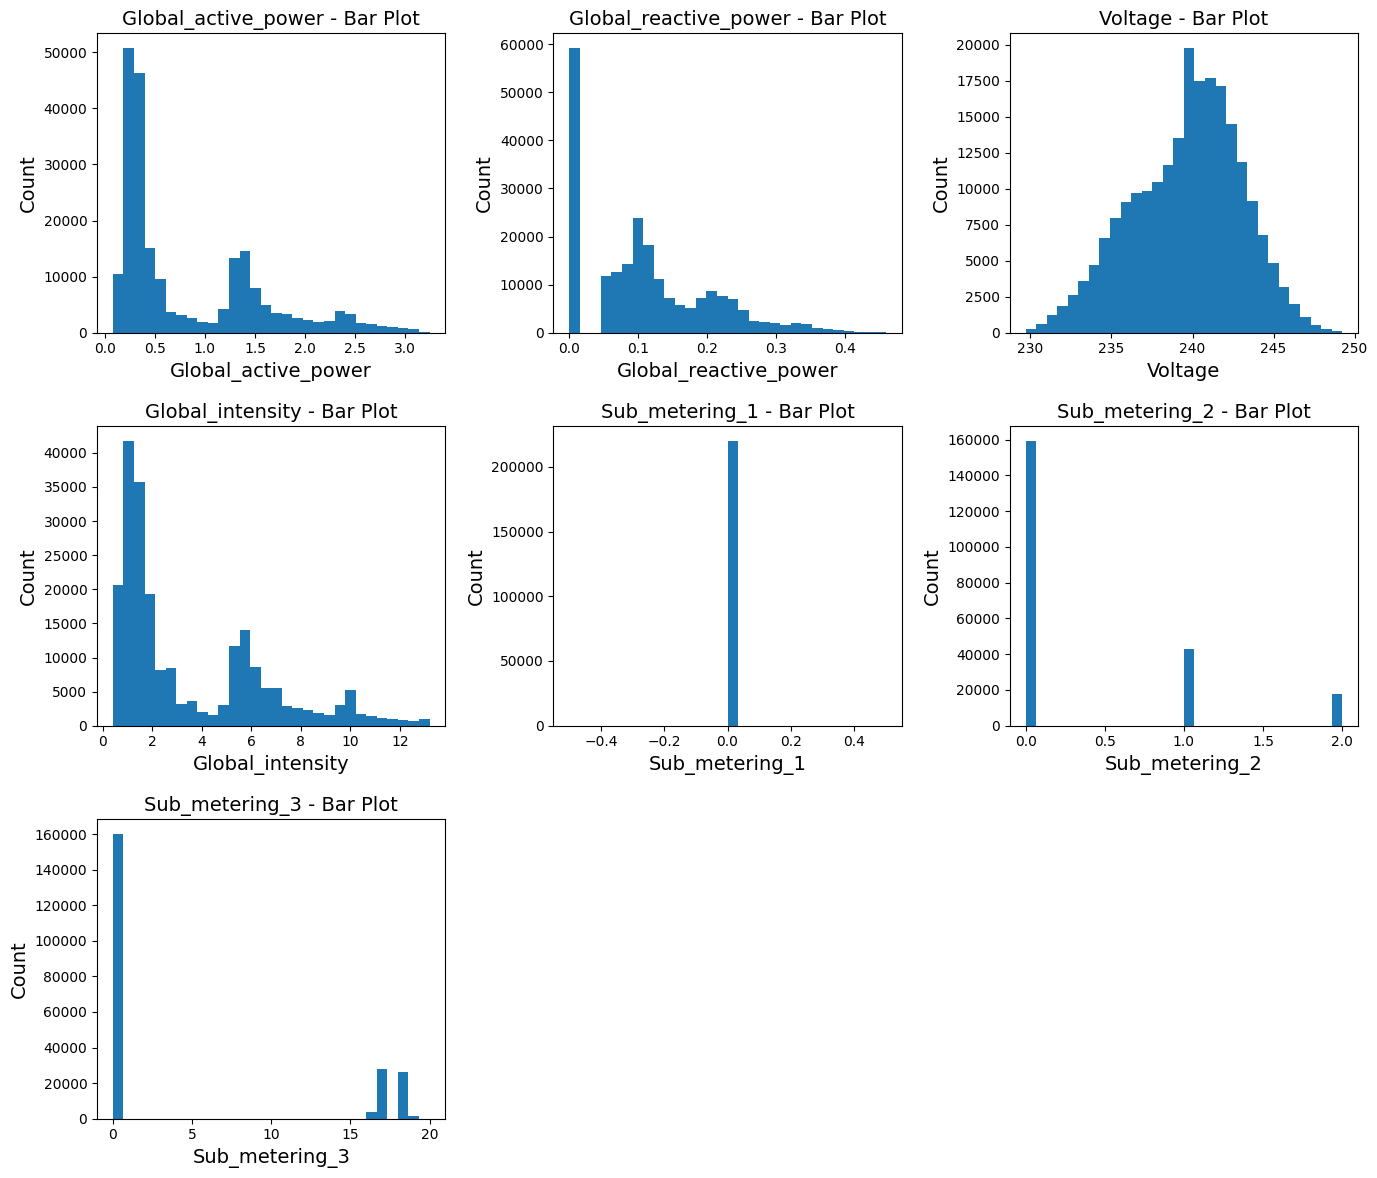

In [143]:
plt.figure(figsize=(14, 12))# Create figure for histogram bar plots

for i, fname in enumerate(num_col1):# Loop through numerical columns in dataset 1
    values = data1[fname].values# Extract values
    
    counts, bins = np.histogram(values, bins=30)# Compute histogram counts and bins
    bin_centers = 0.5 * (bins[1:] + bins[:-1])# Calculate bin centers
    
    plt.subplot(3, 3, i+1)# Create subplot
    plt.bar(bin_centers, counts, width=(bins[1] - bins[0]))# Plot histogram as bar chart
    plt.title(f"{fname} - Bar Plot")# Set labels
    plt.xlabel(fname)
    plt.ylabel("Count")

plt.tight_layout()# Adjust layout
plt.show()# Display plots

### Bar Plot Interpretation 
Most variables are right skewed wich mean higher values occur rarely.
Voltage apears to follow normal distribution.
sub_metering variables has zeros, indicating energy usage in these meters is often low or not active.

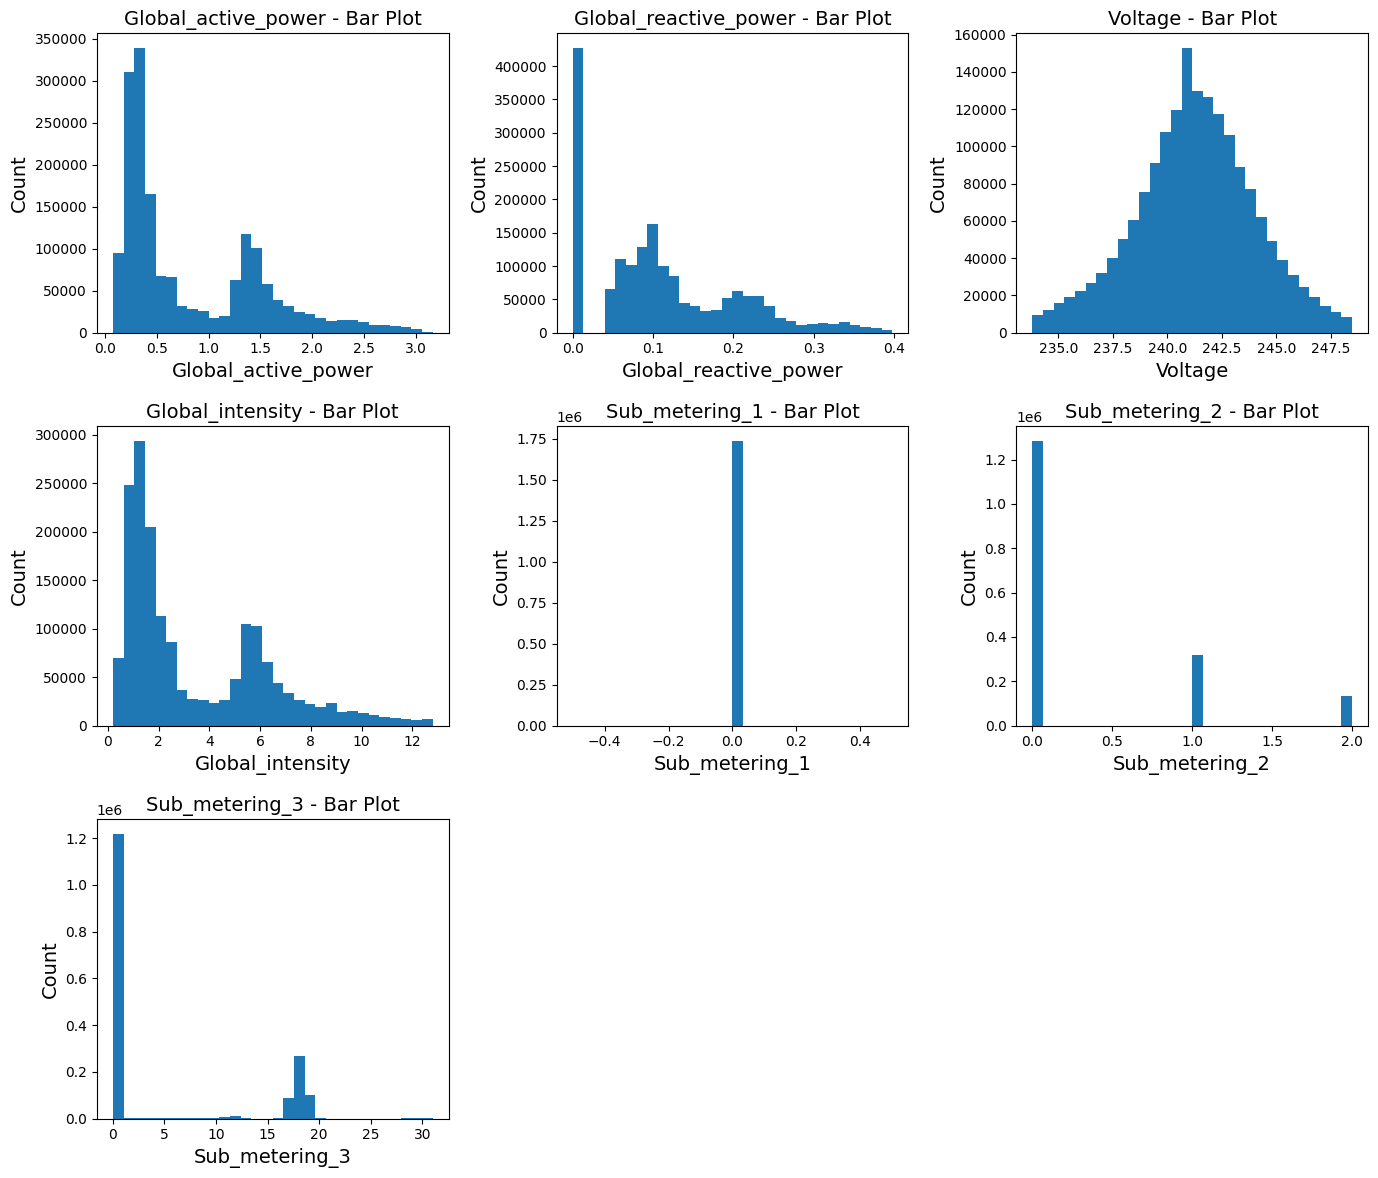

In [144]:
plt.figure(figsize=(14, 12))# Create figure for histogram bar plots

for i, fname in enumerate(num_col2):# Loop through numerical columns in dataset 2
    values = data2[fname].values# Extract values
    
    counts, bins = np.histogram(values, bins=30)# Compute histogram counts and bins
    bin_centers = 0.5 * (bins[1:] + bins[:-1])# Calculate bin centers
    
    plt.subplot(3, 3, i+1)# Create subplot
    plt.bar(bin_centers, counts, width=(bins[1] - bins[0]))# Plot histogram as bar chart
    plt.title(f"{fname} - Bar Plot")# Set labels
    plt.xlabel(fname)
    plt.ylabel("Count")

plt.tight_layout()# Adjust layout
plt.show()# Display plots

### Bar Plot Interpretation data set2
Most variables are right skewed wich mean higher values occur rarely.
Voltage apears to follow normal distribution.
sub_metering variables has zeros, indicating energy usage in these meters is often low or not active.

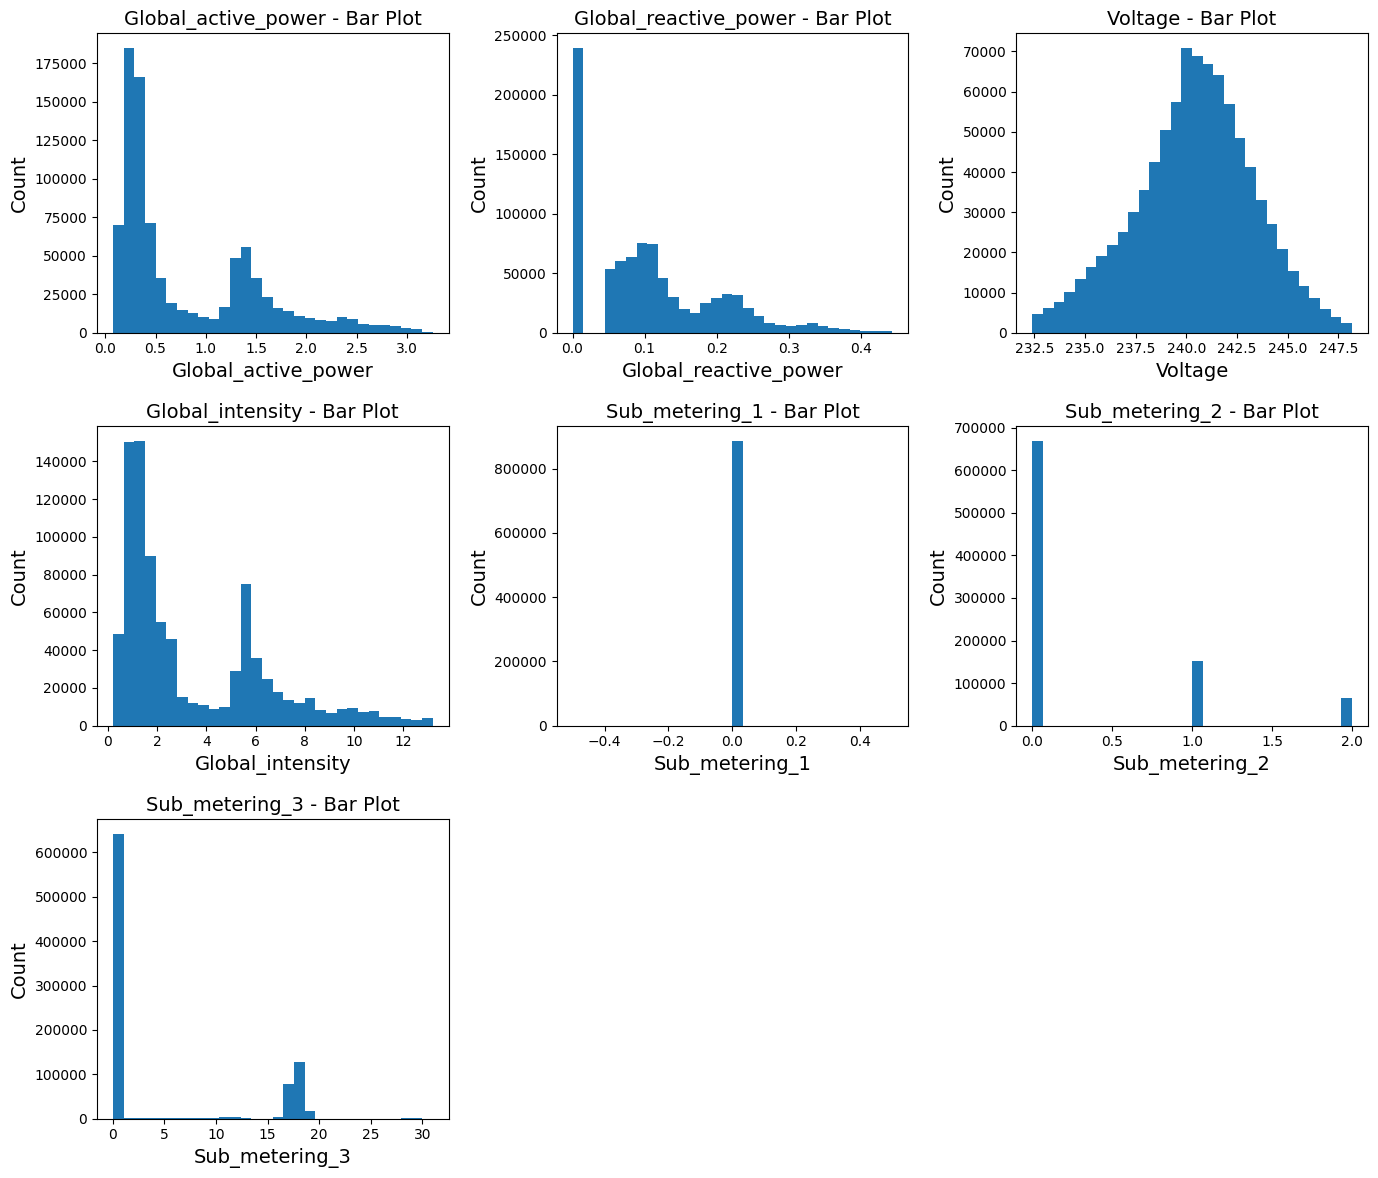

In [145]:
plt.figure(figsize=(14, 12))# Create figure for histogram bar plots

for i, fname in enumerate(num_col3):# Loop through numerical columns in dataset 2
    values = data3[fname].values# Extract values
    
    counts, bins = np.histogram(values, bins=30)# Compute histogram counts and bins
    bin_centers = 0.5 * (bins[1:] + bins[:-1])# Calculate bin centers
    
    plt.subplot(3, 3, i+1)# Create subplot
    plt.bar(bin_centers, counts, width=(bins[1] - bins[0]))# Plot histogram as bar chart
    plt.title(f"{fname} - Bar Plot")# Set labels
    plt.xlabel(fname)
    plt.ylabel("Count")

plt.tight_layout()# Adjust layout
plt.show()# Display plots

### Bar Plot Interpretation data set3
Most variables are right skewed wich mean higher values occur rarely.
Voltage apears to follow normal distribution.
sub_metering variables has zeros, indicating energy usage in these meters is often low or not active.

### Data set merging and Final Data Cleaning
datasets are combined into a single dataset for further analysis and modelling.

In [146]:
merged_data = pd.concat([data1,data2,data3], ignore_index=True)# Merge the three datasets into a dataset and reset the index
print(merged_data.head())#display first 5 rows
print("Dataset Shape: ", merged_data.shape)#display the shape of the merged dataset

         Date     Time  Global_active_power  Global_reactive_power  Voltage  \
0  01/01/2007  0:00:00                2.580                  0.136   241.97   
1  01/01/2007  0:01:00                2.552                  0.100   241.75   
2  01/01/2007  0:02:00                2.550                  0.100   241.64   
3  01/01/2007  0:03:00                2.550                  0.100   241.71   
4  01/01/2007  0:04:00                2.554                  0.100   241.98   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              10.6             0.0             0.0             0.0  
1              10.4             0.0             0.0             0.0  
2              10.4             0.0             0.0             0.0  
3              10.4             0.0             0.0             0.0  
4              10.4             0.0             0.0             0.0  
Dataset Shape:  (2846426, 9)


In [147]:
full_data = merged_data.drop_duplicates(subset=["Date", "Time"])# Remove duplicate based on Date and Time 
print(full_data.shape)#Print shape after removing duplicates

(2549986, 9)


In [148]:
merged_data.isna().sum()#number of missing values after merge

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [149]:
# Fill replace missing values in numerical columns using the median
full_data['Global_active_power'].fillna(full_data['Global_active_power'].median(), inplace=True)
full_data['Global_reactive_power'].fillna(full_data['Global_reactive_power'].median(), inplace=True)
full_data['Voltage'].fillna(full_data['Voltage'].median(), inplace=True)
full_data['Global_intensity'].fillna(full_data['Global_intensity'].median(), inplace=True)
full_data['Sub_metering_1'].fillna(full_data['Sub_metering_1'].median(), inplace=True)
full_data['Sub_metering_2'].fillna(full_data['Sub_metering_2'].median(), inplace=True)
full_data['Sub_metering_3'].fillna(full_data['Sub_metering_3'].median(), inplace=True)

C:\Users\almujtaba\AppData\Local\Temp\ipykernel_20932\1360209962.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  full_data['Global_active_power'].fillna(full_data['Global_active_power'].median(), inplace=True)
C:\Users\almujtaba\AppData\Local\Temp\ipykernel_20932\1360209962.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_data['Glo

In [150]:
merged_data.info()# Display dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2846426 entries, 0 to 2846425
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 195.4+ MB


In [151]:
y = full_data["Global_active_power"].astype(float)
X = full_data.drop(columns=["Global_active_power"])

feature_names = X.columns.tolist()

print("Feature shape:", X.shape, "Target shape: ", y.shape)
print("Features:", feature_names)

#splits the data into different sets the test size means that that percentage will be set aside for test data while the random state keeps the model replicable
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Feature shape: (2549986, 8) Target shape:  (2549986,)
Features: ['Date', 'Time', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
Train: (1784990, 8)
Validation: (382498, 8)
Test: (382498, 8)
